# 02. Neural Network Classification with Pytorch

## 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

#Make 1000 samples
n_samples=1000

#Create circles
X,y=make_circles(n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First five samples of X:\n{X[:5]}")
print(f"First five samples of y:\n{y[:5]}")

First five samples of X:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First five samples of y:
[1 1 1 1 0]


In [5]:
# make dataframe from circles data
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


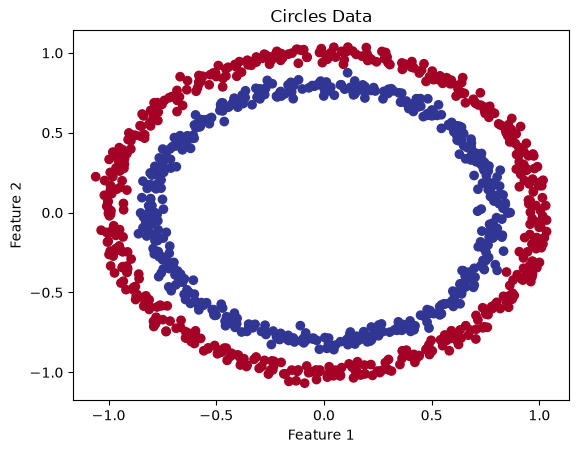

In [6]:
#visualize the data
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Circles Data")
plt.show()

**Note:** The data we are working with is also known as toy dataset. A dataset that is small enough to experiment but still sizeable enough to practice the fundamentals

### 1.1 check inp and out shape

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [9]:
#view the first 5 labels
X_sample=  X[0]
y_sample=  y[0]

print(f"Values for one sample of X:\n{X_sample} and the same for y:\n{y_sample}")
print(f"Shape of one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X:
[0.75424625 0.23148074] and the same for y:
1
Shape of one sample of X: (2,) and the same for y: ()


### 2. Turn data into tensors

In [10]:
#turn data into tensors
import torch
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [12]:
# split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Lets build a model to classify our blue and red dots
to do so we want to:
1. Set up device agnostic code so our code will run on an accelerator(gpu) if there is one
2. Construct a model(by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a traning and test loop

In [14]:
# import pytorch and nn
import torch
from torch import nn

# make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [15]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have setup device agnostic code lets create a model that:
1. Subclasses 'nn.Module' (almost all models in Pytorch subclass 'nn.Module)
2. Create 2 'nn.Linear()' layers that are capable of handling the shapes of our data
3. Defube a forward() method that outlines the forward pass(or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device

In [16]:
#1. Construct a model by subclassing nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=5) # takes in 2 features and outputs 5 features
        self.layer_2=nn.Linear(in_features=5, out_features=1) # takes in 5 features and outputs 1 feature( same shape as y)
    
    # define forward function to define how data moves through the model
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) #x->layer_1-->layer_2-->output

# Instantiate the model and send it to the target device
model_0=CircleModelV0().to(device)
model_0        

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
device

'cuda'

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [19]:
# Lets replicate the model above using nn.sequential
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4051,  0.6464],
                      [-0.0334, -0.5958],
                      [ 0.4791, -0.3979],
                      [-0.6794,  0.0360],
                      [-0.2054,  0.5384]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.1234,  0.3005,  0.5633, -0.5005, -0.6408], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.2751,  0.0511,  0.1293,  0.2846, -0.1181]], device='cuda:0')),
             ('1.bias', tensor([-0.2277], device='cuda:0'))])

In [21]:
# make predictions
untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape:{X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape:torch.Size([200, 2])

First 10 predictions:
tensor([[-0.1442],
        [-0.1314],
        [-0.1875],
        [-0.1319],
        [-0.2029],
        [-0.1949],
        [-0.1466],
        [-0.1615],
        [-0.1868],
        [-0.1307]], device='cuda:0', grad_fn=<SliceBackward0>)

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [22]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 Setup loss function and optimizer

Which loss func and optimizer?

For regression : MAE or MSE

For classification : Binary cross entropy or cross entropy

And for optimizer two common are SGD and Adam

For loss func we are going to use 'torch.nn.BCEWithLogitsLoss()'

In [23]:
# set up loss func
#loss_fn=nn.BCELoss() ## requires inputs to have gone thru the sigmoid activation function prior to input to BCELoss
loss_fn=nn.BCEWithLogitsLoss() #BCEWithLoss= sigmoid activation function built-in

optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)

In [24]:
# calculate accuracy
def accuracy_fn(y_true,y_pred):
    correct=torch.eq(y_true,y_pred).sum().item()
    acc=(correct/len(y_pred))*100
    return acc

## 3. Train model

To train our model we need to build a training loop with same loop structure as used before

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**

We can convert these logits into prediction probabilities by passing them to some kind of activation function (e.g sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our models prediction probabilities to prediction labels by either rounding them or taking the argmax()

In [25]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1442],
        [-0.1314],
        [-0.1875],
        [-0.1319],
        [-0.2029]], device='cuda:0')

In [26]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [27]:
# use sigmoid act func on our model
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4640],
        [0.4672],
        [0.4533],
        [0.4671],
        [0.4495]], device='cuda:0')

For our prediction probabaility value we need to perform a range-style rounding on them:
* y_pred_probs >= 0.5 , y=1(class 1)
* y_preb_probs <0.5, y=0 (class 0)

In [28]:
# find the pred label
y_preds=torch.round(y_pred_probs)

# in full(logits->pred probs-> pred labels)
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [29]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### 3.2 Building a training and testing loop

In [30]:
print(X_train.device)
print(y_train.device)
print(next(model_0.parameters()).device)
print(y_logits.device)


cpu
cpu
cuda:0
cuda:0


In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#set epochs
epochs=100

# put data to target device
X_train, y_train=X_train.to(device), y_train.to(device)
X_test, y_test= X_test.to(device), y_test.to(device)

#building training and evaluating loop
for epoch in range(epochs):
    model_0.train()

    #Forward pass
    y_logits=model_0(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))

    # accuracy
    #loss=loss_fn(torch.sigmoid(y_logits), ## BCELoss expects prediction probability as input
     #            y_train)
    loss=loss_fn(y_logits, ## BCEWithlogits expects logits as raw input
                 y_train)

    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

    #optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #optimizer step
    optimizer.step()

    #testing
    model_0.eval()
    with torch.inference_mode():
        test_logits=model_0(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))

        # calculate test loss
        test_loss=loss_fn(test_logits,
                          y_test)
        test_acc=accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

        # print out whats happen
    if epoch %10==0:
        print(f"Epoch: {epoch} | Loss:{loss:.5f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.5f} , Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss:0.69674,Accuracy:50.00% | Test loss: 0.69771 , Test acc: 50.00%
Epoch: 10 | Loss:0.69633,Accuracy:50.00% | Test loss: 0.69729 , Test acc: 50.00%
Epoch: 20 | Loss:0.69597,Accuracy:50.00% | Test loss: 0.69692 , Test acc: 50.00%
Epoch: 30 | Loss:0.69565,Accuracy:50.00% | Test loss: 0.69659 , Test acc: 50.00%
Epoch: 40 | Loss:0.69536,Accuracy:50.00% | Test loss: 0.69630 , Test acc: 50.00%
Epoch: 50 | Loss:0.69511,Accuracy:50.00% | Test loss: 0.69604 , Test acc: 50.00%
Epoch: 60 | Loss:0.69489,Accuracy:50.00% | Test loss: 0.69581 , Test acc: 50.00%
Epoch: 70 | Loss:0.69470,Accuracy:50.00% | Test loss: 0.69561 , Test acc: 50.00%
Epoch: 80 | Loss:0.69452,Accuracy:50.00% | Test loss: 0.69543 , Test acc: 50.00%
Epoch: 90 | Loss:0.69437,Accuracy:50.00% | Test loss: 0.69527 , Test acc: 50.00%


## 4. Make predictions and evaluate the model

From metrics it looks like our model is not learning anything

So inspect it by visualizing

To do so we are going to import a function called plot_decision_boundary()

In [32]:
import requests
from pathlib import Path
#download helper function from learn pytorch repo (if it is not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_function.py already exist , skipping download")
else:
    print("Download helper_function.py")
    request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py") 
    with open("helper_function.py", "wb") as f:
        f.write(request.content)   

from helper_function import plot_predictions, plot_decision_boundary        

Download helper_function.py


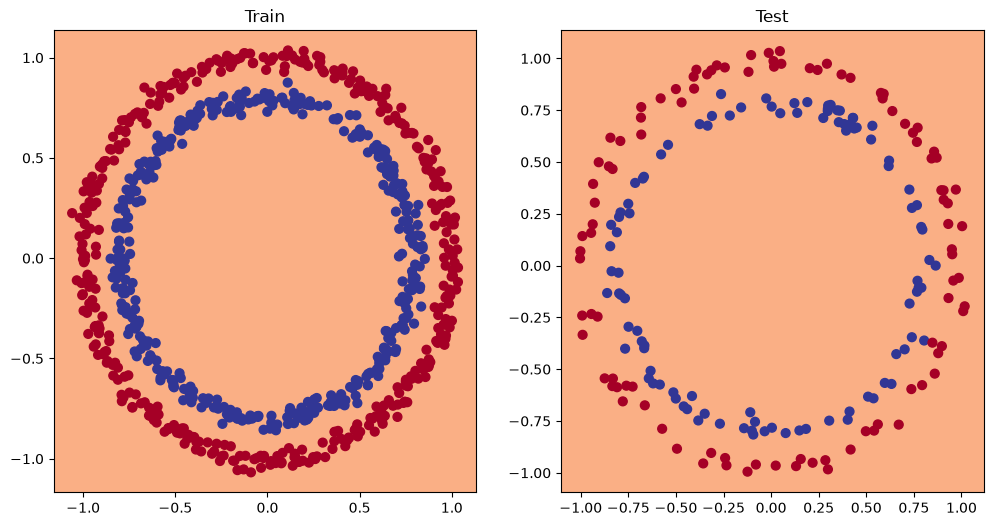

In [33]:
# plot decision boundary of model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

## 5. Improving a Model

* Add more hidden layers so that it can learn more
* Add more hidden units
* Fit for longer
* Changing th activation function
* Changing the learning rate
* Change the loss function

These options are all from model perspective because they deal directly with the model, rather than th data

And bcz these options are all values we (as machine learning engineers) can change, they are referred as hyperparameters

Lets try to improve model by:
* Adding more hidden units: 5-> 10
* Increase the number of layers : 2->3
* Increase the number of epochs: 100-> 1000

In [34]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10, out_features=1)

    def forward(self,x):
        #z=self.layer_1(x)
        #z=self.layer_2(z)
       # z=z=self.layer_3(z)
       return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operation leverages speed up

model_1=CircleModelV1().to(device)
model_1    


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [35]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.4053,  0.6468],
                      [-0.0334, -0.5957],
                      [ 0.4792, -0.3977],
                      [-0.6792,  0.0364],
                      [-0.2055,  0.5381]])),
             ('0.bias', tensor([ 0.1326,  0.3023,  0.5678, -0.4914, -0.6450])),
             ('1.weight',
              tensor([[ 0.2806,  0.0601,  0.1476,  0.2679, -0.1386]])),
             ('1.bias', tensor([-0.1947]))])

In [36]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [37]:
# create a loss function
loss_fn=nn.BCEWithLogitsLoss()

#create a optimizer
optimizer=torch.optim.SGD(params=model_1.parameters(),
                          lr=0.1)


In [38]:
# Training and evaluation loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

#train longer
epochs=1000

# Put data on the target device
X_train, y_train=X_train.to(device), y_train.to (device)
X_test, y_test=X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()
    y_logits=model_1(X_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits, y_train)
    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    model_1.eval()
    with torch.inference_mode():
        test_logits-model_1(X_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))
        test_loss=loss_fn(test_logits,
                          y_test)
        test_acc=accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    if epoch % 10==0:
        print(f"Epoch: {epoch} | Loss:{loss:.5f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.5f} , Test acc: {test_acc:.2f}%")           


Epoch: 0 | Loss:0.69396,Accuracy:50.88% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 10 | Loss:0.69369,Accuracy:50.25% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 20 | Loss:0.69351,Accuracy:50.12% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 30 | Loss:0.69339,Accuracy:50.50% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 40 | Loss:0.69329,Accuracy:50.38% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 50 | Loss:0.69322,Accuracy:49.88% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 60 | Loss:0.69317,Accuracy:49.38% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 70 | Loss:0.69312,Accuracy:49.38% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 80 | Loss:0.69309,Accuracy:50.12% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 90 | Loss:0.69307,Accuracy:50.50% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 100 | Loss:0.69305,Accuracy:50.38% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 110 | Loss:0.69303,Accuracy:50.88% | Test loss: 0.69515 , Test acc: 50.00%
Epoch: 120 | Loss:0.69302,A

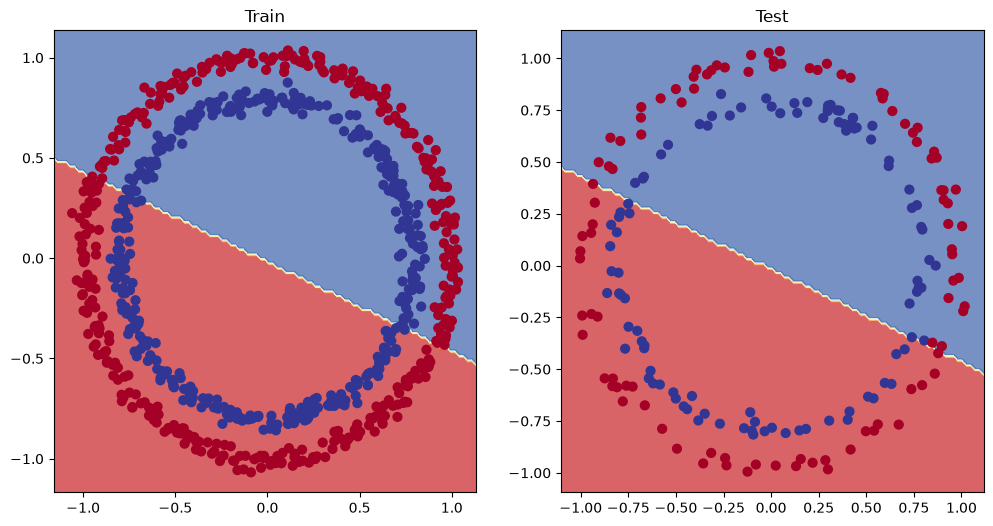

In [39]:
# plot decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a larger problem is to test a smaller problem

In [40]:
# create some data(same as noteboke 01 )
weight=0.7
bias=0.3
start=0
end=1
step=0.01

# create data
x_regression=torch.arange(start, end,step).unsqueeze(dim=1)
y_regression=weight*x_regression+bias

# check data
print(len(x_regression))
x_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [41]:
# create train and test splits
train_split=int(0.8*len(x_regression))
x_train_regression, y_train_regression = x_regression[:train_split], y_regression[:train_split]
x_test_regression, y_test_regression= x_regression[train_split:],y_regression[train_split:]

# check the lenghts
len(x_test_regression), len(x_train_regression), len(y_train_regression),len(y_test_regression)

(20, 80, 80, 20)

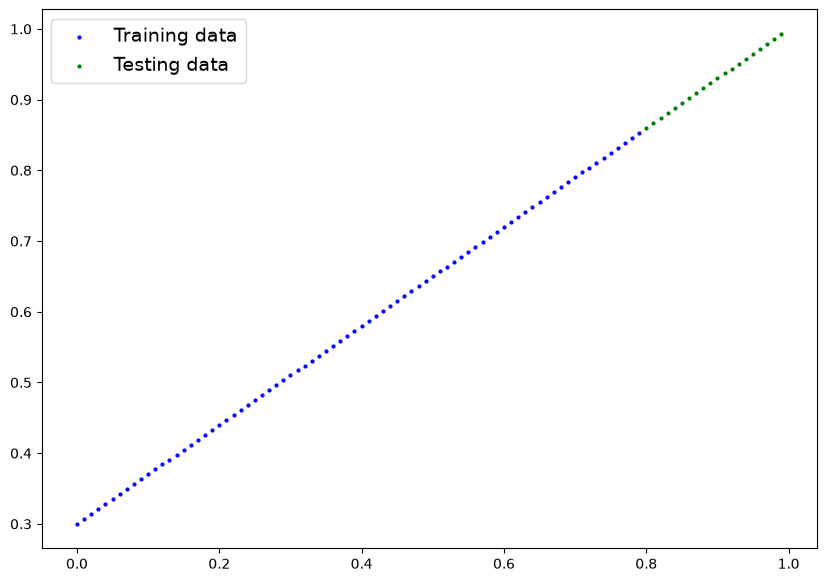

In [42]:
plot_predictions(train_data=x_train_regression,
                train_labels=y_train_regression,
                test_data=x_test_regression,
                test_labels=y_test_regression)

In [43]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

### 5.2 Adjusting  'model_1' to fit a straight line

In [44]:
# same architecture as model_1 but using nn.Sequential()
model_2=nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [45]:
# loss and optimizer
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_2.parameters(),
                          lr=0.01)

In [46]:
# train
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# set epochs
epochs=1000

# put data on target device
x_train_regression, y_train_regression= x_train_regression.to(device), y_train_regression.to(device)
x_test_regression, y_test_regression=x_test_regression.to(device), y_test_regression.to(device)

# training
for epoch in range(epochs):
    y_pred=model_2(x_train_regression)
    loss=loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # testing
    model_2.eval()
    with torch.inference_mode():
        test_pred=model_2(x_test_regression)
        test_loss=loss_fn(test_pred, y_test_regression)

    # print
    if epoch %10==0:
        
        print(f"Epoch: {epoch} | Loss:{loss:.5f} | Test loss: {test_loss:.5f} ")           
        
   

Epoch: 0 | Loss:0.75986 | Test loss: 0.91103 
Epoch: 10 | Loss:0.40240 | Test loss: 0.50474 
Epoch: 20 | Loss:0.06007 | Test loss: 0.10151 
Epoch: 30 | Loss:0.01559 | Test loss: 0.03231 
Epoch: 40 | Loss:0.03092 | Test loss: 0.00111 
Epoch: 50 | Loss:0.03196 | Test loss: 0.00108 
Epoch: 60 | Loss:0.03192 | Test loss: 0.00170 
Epoch: 70 | Loss:0.03081 | Test loss: 0.00097 
Epoch: 80 | Loss:0.03077 | Test loss: 0.00150 
Epoch: 90 | Loss:0.02967 | Test loss: 0.00092 
Epoch: 100 | Loss:0.02858 | Test loss: 0.00081 
Epoch: 110 | Loss:0.02962 | Test loss: 0.00197 
Epoch: 120 | Loss:0.02748 | Test loss: 0.00091 
Epoch: 130 | Loss:0.02852 | Test loss: 0.00181 
Epoch: 140 | Loss:0.02850 | Test loss: 0.00246 
Epoch: 150 | Loss:0.02744 | Test loss: 0.00169 
Epoch: 160 | Loss:0.02638 | Test loss: 0.00123 
Epoch: 170 | Loss:0.02637 | Test loss: 0.00162 
Epoch: 180 | Loss:0.02532 | Test loss: 0.00125 
Epoch: 190 | Loss:0.02636 | Test loss: 0.00284 
Epoch: 200 | Loss:0.02533 | Test loss: 0.00209 
Epo

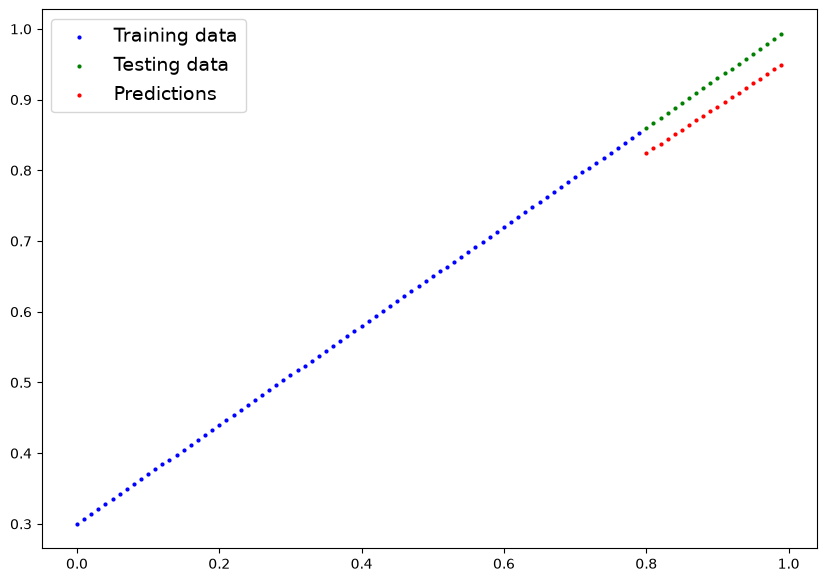

In [47]:
# turn on evaluation mode
model_2.eval()

with torch.inference_mode():
    y_preds=model_2(x_test_regression)

# plot data and predictions
plot_predictions(train_data=x_train_regression.cpu(),  ## plot predictions uses matplot lib which accepts numbers as numpy thats why converting to cpu
                 train_labels=y_train_regression.cpu(),
                 test_data=x_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());    

## 6. The missing piece : Non Linearity

### 6.1 Recreating non-linear data (red and blue circles)

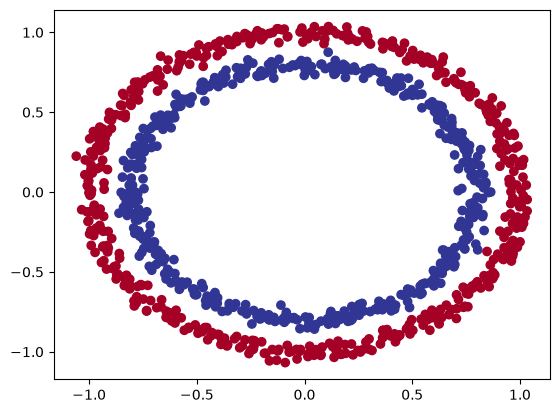

In [48]:
# make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples=1000
x,y=make_circles(n_samples, noise=0.03,random_state=42)

plt.scatter(x[:,0],x[:,1],c=y,cmap="RdYlBu");

In [49]:
# train and test split
import torch
from sklearn.model_selection import train_test_split

x=torch.from_numpy(x).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

x_train,x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non linearity

ANN are large combination of linear and no linear fucntion with potentially able to find patterns in data

In [50]:
#build a model with non linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1=nn.Linear(in_features=2, out_features=10)
        self.layer_2=nn.Linear(in_features=10, out_features=10)
        self.layer_3=nn.Linear(in_features=10,out_features=1)
        self.relu=nn.ReLU() # relu is non linear activation function
    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_3=CircleModelV2().to(device)
model_3    


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [51]:
# setup loss and optimizer
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_3.parameters(),
                          lr=0.1)

###  6.4 Train model with non linearity

In [52]:
# random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# put data in target device
x_train, y_train= x_train.to(device), y_train.to(device)
x_test, y_test=x_test.to(device), y_test.to(device)

# loop
epochs=1000

for epoch in range(epochs):
    model_3.train()
    y_logits=model_3(x_train).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits,y_train)
    acc=accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # testing
    model_3.eval()
    with torch.inference_mode():
        test_logits=model_3(x_test).squeeze()
        test_pred=torch.round(torch.sigmoid(test_logits))

        test_loss=loss_fn(test_logits,y_test)
        test_acc=accuracy_fn(y_true=y_test, y_pred=test_pred)

    # print
    if epoch%100==0:
         print(f"Epoch: {epoch} | Loss:{loss:.4f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.4f} , Test acc: {test_acc:.2f}%")           



Epoch: 0 | Loss:0.6929,Accuracy:50.00% | Test loss: 0.6932 , Test acc: 50.00%
Epoch: 100 | Loss:0.6912,Accuracy:52.88% | Test loss: 0.6910 , Test acc: 52.50%
Epoch: 200 | Loss:0.6898,Accuracy:53.37% | Test loss: 0.6894 , Test acc: 55.00%
Epoch: 300 | Loss:0.6879,Accuracy:53.00% | Test loss: 0.6872 , Test acc: 56.00%
Epoch: 400 | Loss:0.6852,Accuracy:52.75% | Test loss: 0.6841 , Test acc: 56.50%
Epoch: 500 | Loss:0.6810,Accuracy:52.75% | Test loss: 0.6794 , Test acc: 56.50%
Epoch: 600 | Loss:0.6751,Accuracy:54.50% | Test loss: 0.6729 , Test acc: 56.00%
Epoch: 700 | Loss:0.6666,Accuracy:58.38% | Test loss: 0.6632 , Test acc: 59.00%
Epoch: 800 | Loss:0.6516,Accuracy:64.00% | Test loss: 0.6476 , Test acc: 67.50%
Epoch: 900 | Loss:0.6236,Accuracy:74.00% | Test loss: 0.6215 , Test acc: 79.00%


In [53]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.6760,  0.8035],
                      [-0.1997,  0.7568],
                      [-0.1549,  0.1427],
                      [-0.9637,  0.2292],
                      [ 0.5717, -1.3426],
                      [ 0.6689,  0.1840],
                      [ 0.7970,  0.2595],
                      [ 0.3410, -0.0998],
                      [ 0.6555,  0.3186],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3761, -0.2008, -0.2872,  0.2803, -0.4513, -0.3364, -0.3300, -0.4252,
                      -0.1989, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 1.3081e-01, -3.7347e-01,  2.4414e-01, -4.3348e-02, -2.7270e-01,
                        1.0512e-01, -4.7109e-02,  2.5550e-01, -4.9248e-02, -9.9730e-02],
                      [ 7.9469e-01,  3.8277e-01,  1.3309e-01,  7.5399e-01,  9.7241e-01,
                        2.6996e-01,  6.2185e-01

### 6.4 Evaluating our model trained with non linear activation functions

In [54]:
# make predictions
model_3.eval()
with torch.inference_mode():
    y_preds=torch.round(torch.sigmoid(model_3(x_test))).squeeze()
y_preds[:10], y_test[:10]    

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

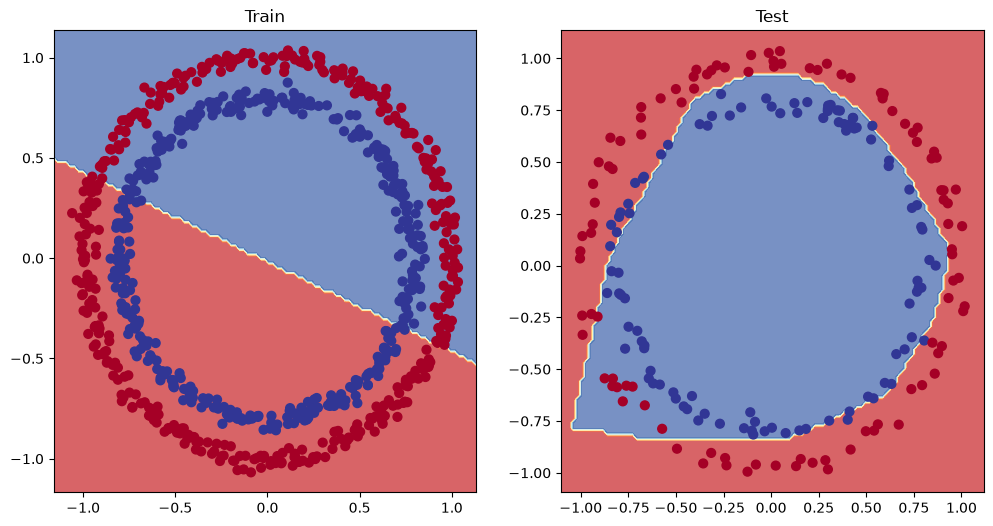

In [55]:
# plot decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,x_test,y_test)

## 7. Replicating non linear activation functions

Neural networks rather than us telling the model what to learn , we give it the tools to discover patterns in data and it tries to figure out the patterns on its own

And these tools are linear and non linear functions

In [56]:
# create a tensor
A=torch.arange(-10,10,1, dtype=torch.float32)
A.dtype

torch.float32

In [57]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

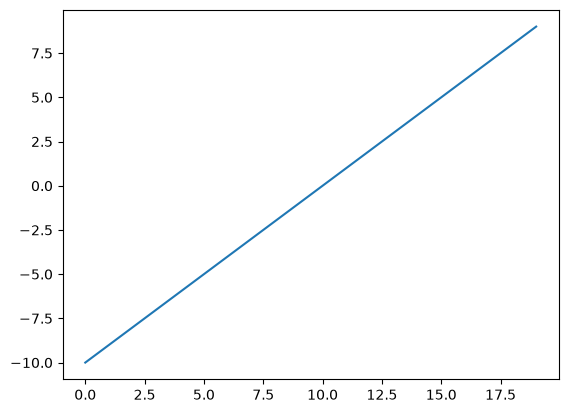

In [58]:
# visualize
plt.plot(A)

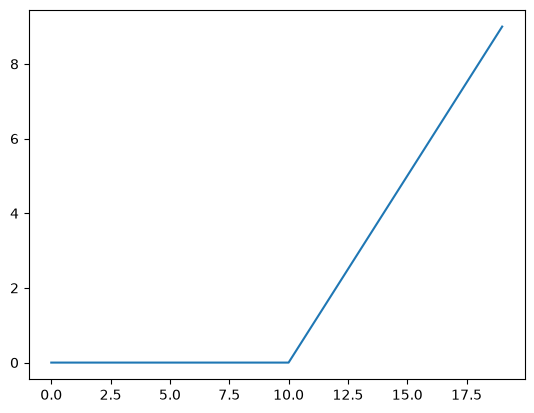

In [59]:
plt.plot(torch.relu(A))

In [60]:
def relu(x):
    return torch.maximum(torch.tensor(0),x) # input must be tensor
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

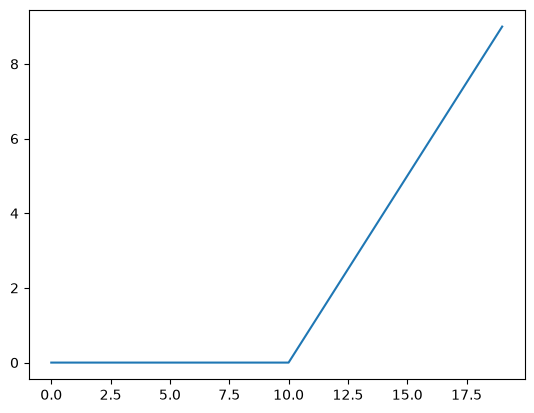

In [61]:
#plot relu activation function
plt.plot(relu(A)); 

In [62]:
# lets do same for sigmoid
def sigmoid(x):
    return 1/(1+torch.exp(-x))

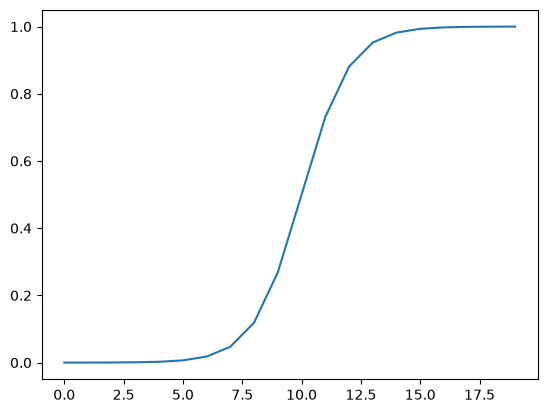

In [63]:
plt.plot(torch.sigmoid(A));

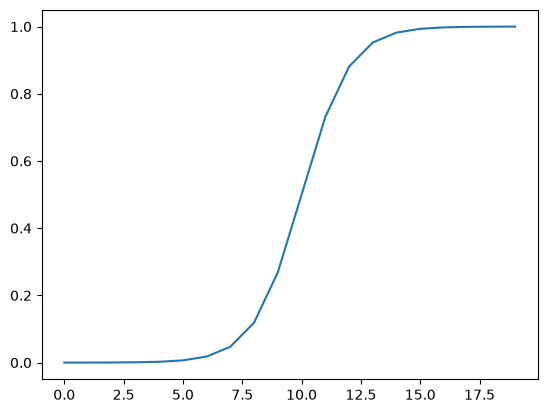

In [64]:
plt.plot(sigmoid(A))

## 8. Putting it all together with a multi class classification problem

### 8.1 creating a toy multi class dataset


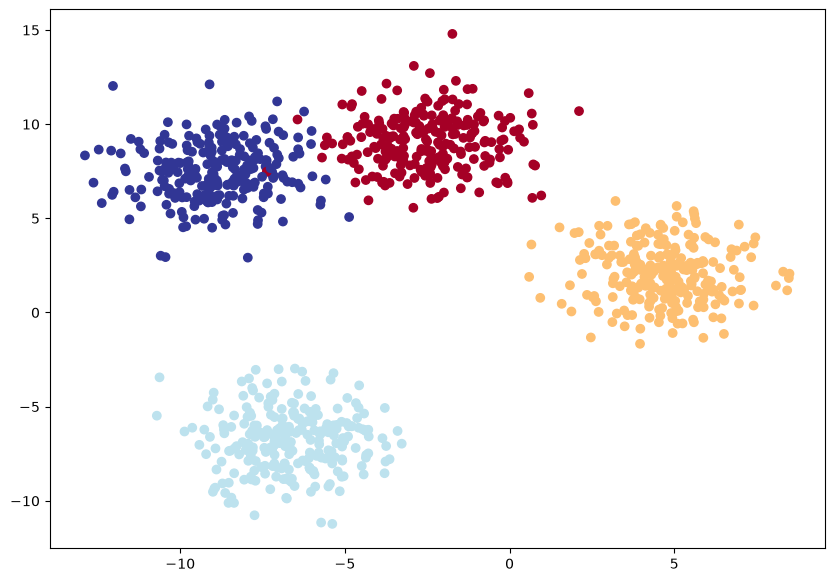

In [83]:
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# set the hyper parameters
num_classes=4
num_features=2
random_seed=42

# create multi class data
x_blob, y_blob=make_blobs(n_samples=1000,
                          n_features=num_features,
                          centers=num_classes,
                          cluster_std=1.5,
                          random_state=random_seed)

# turn data into tensors 
x_blob=torch.from_numpy(x_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)

# split
x_blob_train,x_blob_test,y_blob_train,y_blob_test=train_test_split(x_blob,y_blob,test_size=0.2, random_state=random_seed)

# plot
plt.figure(figsize=(10,7))
plt.scatter(x_blob[:,0],x_blob[:,1],c=y_blob,cmap="RdYlBu");




### 8.2 Building a multi class classification model in Pytorch

In [66]:
# create device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [84]:
# build a multiclass classification model
class BlobModel(nn.Module):
    def __init__(self,input_features, output_features, hidden_units=8):
        """Initializes multi class classification model.

        Args:
        input_features(int: Number of input features to the model
        output_features(int): Number of output features (number of output classes)
        hidden_units(int): Number of hidden units between layers , default 8
        """
        super().__init__()
        self.linear_layer_stack=nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
    def forward(self,x):
        return self.linear_layer_stack(x)    

# create an instance of BlobModel and send it to the target device 
model_4=BlobModel(input_features=2,
                  output_features=4,
                  hidden_units=8).to(device)
model_4    



BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [85]:
x_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [86]:
torch.unique(y_blob_train)

tensor([0, 1, 2, 3])

### 8.3 create a loss func and optimizer for multi class classification problem

In [87]:
# create a loss function and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_4.parameters(),
                          lr=0.1)


### 8.4 Getting predictions probabilities for a multi class pytorch model

In order to evaluate and train and test our model, we need to convert our model outputs (logits) to prediction probabilities and then to prediction labels.

Logits(raw output of model)-> pred probs(use torch.softmax)-> pred labels( take the argmax of the predictions probabilities)

In [92]:
# lets get some raw outputs of model
model_4.eval()
with torch.inference_mode():
    y_logits=model_4(x_blob_test.to(device))

y_logits[:10]    

tensor([[ 0.7111, -0.5330,  0.3307, -0.2327],
        [-0.3420, -1.7850, -0.3224, -1.1384],
        [ 0.1878, -0.8563,  0.3375, -0.9026],
        [ 0.4513, -0.4277,  0.2498, -0.1940],
        [ 0.8922, -0.9492,  0.3245, -0.5287],
        [-0.4885, -2.0119, -0.4004, -1.3252],
        [ 0.2586, -0.8477,  0.2739, -0.8695],
        [ 0.6816, -1.1144,  0.2053, -0.6434],
        [ 0.3433, -1.0156,  0.4706, -1.1226],
        [ 0.7687, -1.0243,  0.2629, -0.5887]], device='cuda:0')

In [88]:
x_blob_test.device

device(type='cpu')

In [89]:
next(model_4.parameters()).device

device(type='cuda', index=0)

In [91]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [93]:
# convert our model logit output to prediction probabilities
y_pred_probs=torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])


tensor([[ 0.7111, -0.5330,  0.3307, -0.2327],
        [-0.3420, -1.7850, -0.3224, -1.1384],
        [ 0.1878, -0.8563,  0.3375, -0.9026],
        [ 0.4513, -0.4277,  0.2498, -0.1940],
        [ 0.8922, -0.9492,  0.3245, -0.5287]], device='cuda:0')
tensor([[0.4236, 0.1221, 0.2895, 0.1648],
        [0.3694, 0.0873, 0.3767, 0.1666],
        [0.3509, 0.1235, 0.4076, 0.1179],
        [0.3627, 0.1506, 0.2965, 0.1902],
        [0.5084, 0.0806, 0.2882, 0.1228]], device='cuda:0')


In [94]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0')

In [95]:
torch.max(y_pred_probs[0])

tensor(0.4236, device='cuda:0')

In [96]:
torch.argmax(y_pred_probs[0])


tensor(0, device='cuda:0')

In [97]:
# convert our model predictions probabilities to prediction labels
y_preds=torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2,
        2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0,
        2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2,
        0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2,
        2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
        2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0,
        2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0,
        0, 2, 2, 0, 2, 0, 2, 0], device='cuda:0')

In [98]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### 8.5 Create a training and testing loop for a multi class Pytorch model

In [101]:
# fit the multi class model to device
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs=100

x_blob_train, y_blob_train=x_blob_train.to(device), y_blob_train.to(device)
x_blob_test,y_blob_test=x_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()
    y_logits=model_4(x_blob_train)
    y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)

    loss=loss_fn(y_logits,y_blob_train)
    acc=accuracy_fn(y_true=y_blob_train,
                    y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # testing 
    model_4.eval()
    with torch.inference_mode():
        test_logits=model_4(x_blob_test)
        test_preds=torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss=loss_fn(test_logits, y_blob_test)
        test_acc=accuracy_fn(y_true=y_blob_test,
                             y_pred=test_preds)

    # print
    if epoch % 10==0:
        print(f"Epoch: {epoch} | Loss:{loss:.4f},Accuracy:{acc:.2f}% | Test loss: {test_loss:.4f} , Test acc: {test_acc:.2f}%")          
        

Epoch: 0 | Loss:1.1950,Accuracy:70.62% | Test loss: 1.0250 , Test acc: 78.00%
Epoch: 10 | Loss:0.6411,Accuracy:72.88% | Test loss: 0.5384 , Test acc: 79.50%
Epoch: 20 | Loss:0.4902,Accuracy:73.12% | Test loss: 0.4069 , Test acc: 79.00%
Epoch: 30 | Loss:0.4015,Accuracy:81.12% | Test loss: 0.3310 , Test acc: 84.50%
Epoch: 40 | Loss:0.3324,Accuracy:88.25% | Test loss: 0.2731 , Test acc: 90.00%
Epoch: 50 | Loss:0.2534,Accuracy:95.38% | Test loss: 0.2048 , Test acc: 98.00%
Epoch: 60 | Loss:0.1541,Accuracy:98.50% | Test loss: 0.1229 , Test acc: 99.00%
Epoch: 70 | Loss:0.0925,Accuracy:98.88% | Test loss: 0.0741 , Test acc: 99.00%
Epoch: 80 | Loss:0.0664,Accuracy:98.88% | Test loss: 0.0532 , Test acc: 99.00%
Epoch: 90 | Loss:0.0540,Accuracy:98.88% | Test loss: 0.0432 , Test acc: 99.00%


### 8.6 Making and evaluating predictions with a pytorch multi class model

In [102]:
model_4.eval()
with torch.inference_mode():
    y_logits=model_4(x_blob_test)

# view the first 10 predictions
y_logits[:10]    

tensor([[ 0.9944,  4.9908, -2.3592, -0.9316],
        [-1.5310, -6.6200, -8.1603,  3.7310],
        [-3.8076, -3.0363,  5.2139, -2.5236],
        [-0.1480,  3.6090, -1.3705, -0.3944],
        [ 6.0518,  2.6616, -5.1601, -1.9860],
        [-2.2358, -8.2144, -9.5390,  4.6999],
        [-3.6027, -2.8526,  4.8562, -2.3319],
        [ 5.0917, -0.2252, -6.0836, -0.7838],
        [-4.3694, -3.6392,  6.3002, -3.1482],
        [ 5.3427,  0.8123, -5.6498, -1.2069]], device='cuda:0')

In [103]:
# go from logits to prediction prob
y_preb_probs=torch.softmax(y_logits,dim=1)
y_pred_probs

tensor([[0.4236, 0.1221, 0.2895, 0.1648],
        [0.3694, 0.0873, 0.3767, 0.1666],
        [0.3509, 0.1235, 0.4076, 0.1179],
        [0.3627, 0.1506, 0.2965, 0.1902],
        [0.5084, 0.0806, 0.2882, 0.1228],
        [0.3645, 0.0795, 0.3981, 0.1579],
        [0.3745, 0.1239, 0.3803, 0.1212],
        [0.4871, 0.0808, 0.3025, 0.1295],
        [0.3812, 0.0979, 0.4329, 0.0880],
        [0.4934, 0.0821, 0.2975, 0.1270],
        [0.4639, 0.0832, 0.3153, 0.1376],
        [0.4282, 0.1196, 0.2897, 0.1626],
        [0.5103, 0.0791, 0.2903, 0.1203],
        [0.5113, 0.0739, 0.2952, 0.1197],
        [0.5258, 0.0706, 0.2897, 0.1140],
        [0.3875, 0.0884, 0.3620, 0.1621],
        [0.3653, 0.0869, 0.3840, 0.1639],
        [0.3783, 0.1188, 0.3878, 0.1151],
        [0.3984, 0.0756, 0.3728, 0.1532],
        [0.3542, 0.0931, 0.4100, 0.1427],
        [0.4080, 0.0807, 0.3586, 0.1528],
        [0.4545, 0.0917, 0.3108, 0.1430],
        [0.3596, 0.1497, 0.3042, 0.1866],
        [0.3446, 0.1364, 0.3833, 0

In [104]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

In [105]:
# go from pred probs to pred labels
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds[:10]

tensor([0, 2, 2, 0, 0, 2, 2, 0, 2, 0], device='cuda:0')

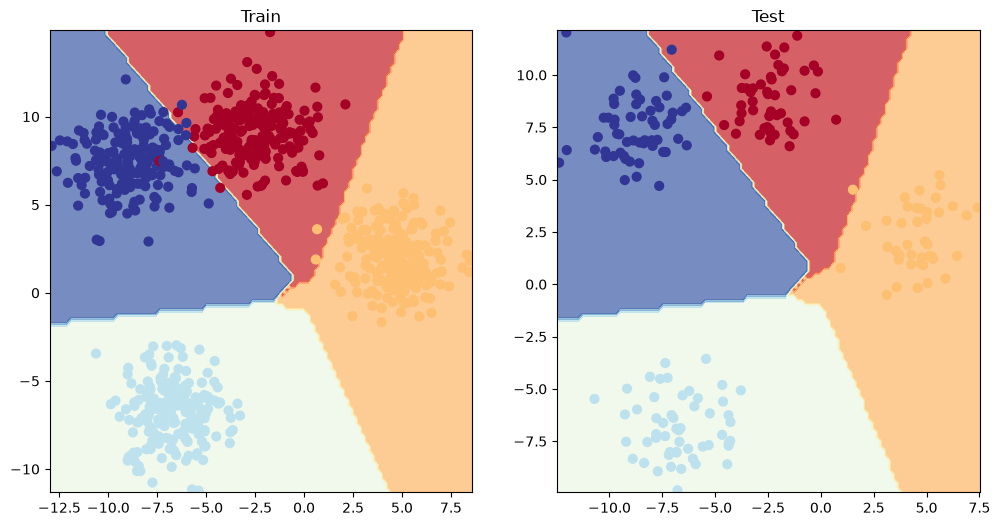

In [106]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,x_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4,x_blob_test,y_blob_test)

## 9. A few more classification metrics

* Accuracy- out of 100 samples , how many does our model get right
* Precision
* Recall
* F1-Score
* Confusuon matrix
* Classification report

In [109]:
import torchmetrics

In [117]:
from torchmetrics import Accuracy

# set uo metric
torchmetric_accuracy=Accuracy(task="multiclass",num_classes=4).to(device)

# calculate accuracy
torchmetric_accuracy(y_preds,y_blob_test)

tensor(0.5100, device='cuda:0')